# Peak Fitting

## Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import NyquistPlot, DRTPlot, ResidualsPlot, PolarisationPlot
from redoxed.impedance import EISData, DRTData, ResidualsData
from redoxed.impedance.drt_analysis import HN_Z, HN_DRT, SG_DRT, fit_DRT_peaks, find_DRT_peaks
from redoxed.dc import PolarisationData

from redoxed import config
config.set_latex_mode(False) # warning, slows plotting if True. Used to achieve consistent serif fonts by rendering latex. 

%matplotlib inline

# if think is slowing down, disable autoreload by restarting kernel without it.
%load_ext autoreload
%autoreload 2 


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Synthetic DRT

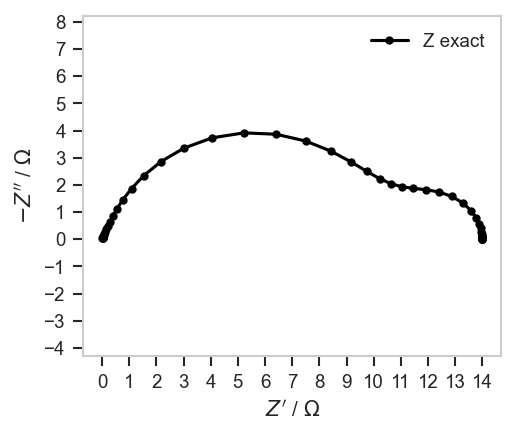

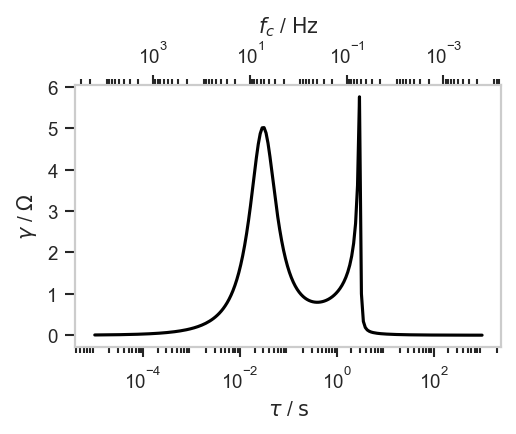

,label,peak_type,peak_number,log_tau0,Z0,alpha,beta,tau0,Z
0,peak_0,HN,0,-3.506132,10.000634,0.800070,0.999221,0.030013,10.000634
1,peak_1,HN,1,1.098600,3.999910,0.989994,0.500050,2.999963,3.999910


{'success': True,
 'message': 'Fit succeeded.',
 'chisqr': np.float64(6.184689176320425e-05),
 'redchi': np.float64(3.2211922793335543e-07),
 'nfev': 160}

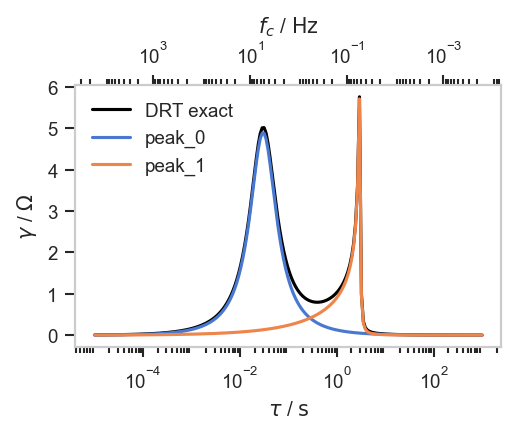

In [ ]:
# Define HN parameters
Z0_1 = 4.0      # Characteristic impedance (Ohm)
tau0_1 = 3.0e0      # Characteristic time constant (s)
alpha_1 = 0.99    # Symmetric broadening parameter
beta_1 = 0.5     # Asymmetric broadening parameter

Z0_2 = 10.0      # Characteristic impedance (Ohm)
tau0_2 = 3.0e-2      # Characteristic time constant (s)
alpha_2 = 0.8    # Symmetric broadening parameter
beta_2 = 1     # Asymmetric broadening parameter

# Create frequency array
f = np.logspace(-4, 4, 50)  # Frequency in Hz decade spacing
omega = 2 * np.pi * f        # Angular frequency in rad/s

# Create time constant array
tau = np.logspace(-5, 3, 200)  # Time constants in s
# tau = 1/omega
# tau = tau[::-1]

# Calculate impedance (analytic HN)
Z = HN_Z(omega, Z0_1, tau0_1, alpha_1, beta_1) + HN_Z(omega, Z0_2, tau0_2, alpha_2, beta_2)
# Calculate DRT
gamma = HN_DRT(tau, Z0_1, tau0_1, alpha_1, beta_1) + HN_DRT(tau, Z0_2, tau0_2, alpha_2, beta_2)


# Get tab10 colors and names (colorblind friendly)
cmap = plt.get_cmap('tab10')
tab10_names = [
    "blue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan"]
tab10_colors = cmap.colors
# Create a name-to-color dictionary
colour_dict = dict(zip(tab10_names, tab10_colors))
colour_dict["black"] = (0, 0, 0) # add black color

# initialise plot dictionaries
eis_plot_dict = {}
drt_plot_dict = {}
# residuals_plot_dict = {}

EISData_object = EISData(Z=Z, f=f)
EISData_object.label = "Z exact"
eis_plot_dict[EISData_object.label] = {
        "data": EISData(Z=Z, f=f),
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": ".", "label": EISData_object.label},
        "plot": True
    }

DRTData_object = DRTData(gamma=gamma, tau=tau)
DRTData_object.label = "DRT exact"
drt_plot_dict[DRTData_object.label] = {
        "data": DRTData(gamma=gamma, tau=tau),
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": DRTData_object.label},
        "plot": True
    }

# observed = EISData(Z=Z, f=f)
# predicted = EISData(Z=Z_DRT_vec, f=f)
# residuals_plot_dict[EISData_object.label] = {
#         "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
#         "plot_kwargs": {"color": colour_dict["red"], "linestyle": "", "mfc": "none", "label": EISData_object.label},
#         "plot": True
#     }


#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(3.543, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# # NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

#########################
#### Create DRT Plot ####
#########################
DRTPlot_object = DRTPlot(figsize=(3.543, 3), dpi = 150)
for label, entry in drt_plot_dict.items():
    if entry["plot"]:
        DRTPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
DRTPlot_object.add_major_ticks(spacing_y = 1)
# DRTPlot_object.add_minor_ticks(number_x = 9)
DRTPlot_object.add_fc_axis() # only use after enforcing DRTPlot_object.ax.set_xlim([0, None]) if desired
DRTPlot_object.fig.tight_layout() # try stop cutting off labels
display(DRTPlot_object.fig)
# DRTPlot_object.save("DRT.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

###########################
## Create Residuals Plot ##
###########################
# # ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'relative') # gets a bit misleading for small Z
# ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'absolute')
# for label, entry in residuals_plot_dict.items():
#     if entry["plot"]:
#         ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
# ResidualsPlot_object.ax.legend()
# display(ResidualsPlot_object.fig)

##################
## Peak fitting ##
##################

peak_positions = find_DRT_peaks(DRTData_object = DRTData_object, num_peaks = None, find_peaks_settings = dict(height=None, threshold=None, distance=None, prominence=None, width=None, wlen=None, rel_height=0.5, plateau_size=None))
# minimizer_settings = {"method": "leastsq", "fit_kws": {"ftol": 1e-8, "xtol": 1e-8, "gtol": 1e-8}}
minimizer_settings = {"method": "leastsq", "fit_kws": {}}
# minimizer_settings = {"method": "leastsq", "fit_kws": {"ftol": 1e-10, "xtol": 1e-10, "gtol": 1e-10}}
# minimizer_settings = {"method": "powell", "fit_kws": {}} # did slightly worse than leastsq
# minimizer_settings = {"method": "least_squares", "fit_kws": {}} # again, slightly worse
# minimizer_settings = {"method": "nelder", "fit_kws": {}} # slightly worse
# minimizer_settings = {"method": "lbfgsb", "fit_kws": {}} # much worse with defaults
# may also increase accuracy with more tau points
log_tau0_bound = 0.1 # about 10%, made fit much better due to easing contraint on tau0
peak_fit = fit_DRT_peaks(
    DRTData_object = DRTData_object,
    peak_positions = peak_positions, # if make none, uses num_peaks to find
    num_peaks =  None, # None if using peak positions instead
    peak_type = "HN", # select HN or SG
    skew = True,
    log_tau0_bound = log_tau0_bound, # base e not 10
    minimizer_settings = minimizer_settings
    
    )
display(peak_fit.to_peaks_df())
display(peak_fit.fit_summary)

for peak in peak_fit:
    DRTPlot_object.add_plot(DRTData(tau = tau, gamma = peak.get_gamma(tau=tau), label = peak.label))
DRTPlot_object.ax.legend()
display(DRTPlot_object.fig)
